In [1]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils import data
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
KAGGLE_DATA = '/kaggle/input/datasets/qwerte123/hetero-data-updated-diffemb/heterodata_object12_updated.pt'
LOCAL_DATA  = r'C:\Users\Admin\Documents\GitHub\PLUM_implementation\data\heterodata_object12_updated.pt'
DATA_PATH   = KAGGLE_DATA if os.path.exists(KAGGLE_DATA) else LOCAL_DATA

df = torch.load(DATA_PATH, weights_only=False, map_location='cpu')
df

HeteroData(
  item={
    x=[12101, 100],
    text=[12101, 2],
    related=[12101],
    is_train=[12101],
  },
  (user, rated, item)={
    history={
      train={
        item_ID=[22363],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      valid={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      test={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
    },
  }
)

In [4]:
class Encoder(nn.Module):
    """MLP encoder/decoder with LayerNorm after each hidden layer."""
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        dims = [input_dim] + list(hidden_dims) + [output_dim]
        for i, (in_d, out_d) in enumerate(zip(dims[:-1], dims[1:])):
            layers.append(nn.Linear(in_d, out_d, bias=True))
            if i < len(dims) - 2:          # not last layer
                layers.append(nn.LayerNorm(out_d))
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [5]:
class EMACodebook(nn.Module):
    """
    Vector-quantization codebook with Exponential Moving Average updates.
    - Codebook entries tracked as buffers (not optimizer parameters)
    - K-means initialization on the first training batch
    - Laplace smoothing to keep dead codes alive
    - Cosine distance for assignment (scale-invariant)
    """
    def __init__(self, codebook_size, emb_dim, beta=0.25, ema_decay=0.99, epsilon=1e-4):
        super().__init__()
        self.codebook_size = codebook_size
        self.beta          = beta
        self.ema_decay     = ema_decay
        self.epsilon       = epsilon

        emb = F.normalize(torch.randn(codebook_size, emb_dim), p=2, dim=1)
        self.register_buffer('emb',         emb)
        self.register_buffer('ema_count',   torch.ones(codebook_size))
        self.register_buffer('ema_weight',  emb.clone())
        self.register_buffer('initialized', torch.zeros(1, dtype=torch.bool))

    @torch.no_grad()
    def _kmeans_init(self, x):
        """Initialize codebook with a random sample of encoder outputs."""
        n = x.shape[0]
        if n >= self.codebook_size:
            idx = torch.randperm(n, device=x.device)[:self.codebook_size]
            init = x[idx]
        else:
            repeats = (self.codebook_size // n) + 1
            init    = x.repeat(repeats, 1)[:self.codebook_size]
        self.emb.copy_(F.normalize(init, p=2, dim=1))
        self.ema_weight.copy_(self.emb)
        self.initialized.fill_(True)

    @torch.no_grad()
    def _ema_update(self, x, ids):
        one_hot = F.one_hot(ids, self.codebook_size).float()  
        n_k = one_hot.sum(0)                               
        m_k = one_hot.T @ x                               

        self.ema_count.mul_(self.ema_decay).add_(n_k   * (1 - self.ema_decay))
        self.ema_weight.mul_(self.ema_decay).add_(m_k  * (1 - self.ema_decay))

        n_total = self.ema_count.sum()
        count_smooth = (
            (self.ema_count + self.epsilon) /
            (n_total + self.codebook_size * self.epsilon) * n_total
        )
        self.emb.copy_(self.ema_weight / count_smooth.unsqueeze(1))

    def forward(self, x):
        if self.training and not self.initialized:
            self._kmeans_init(x.detach())

        x_n = F.normalize(x,        p=2, dim=1)
        code_n = F.normalize(self.emb, p=2, dim=1)
        dist = 1.0 - x_n @ code_n.T          
        ids = dist.argmin(dim=1)           
        emb = self.emb[ids]                 

        if self.training:
            self._ema_update(x.detach(), ids)

        commitment_loss = self.beta * F.mse_loss(x, emb.detach())
        emb_st = x + (emb - x).detach()        
        return commitment_loss, emb_st, ids

In [ ]:
class RQVAE_AntiContrastive(nn.Module):
    def __init__(self, inp_size, hidden_sizes, embed_dim, n_layers,
                 codebook_size=256, beta=0.25, gamma=0.1,
                 ema_decay=0.99, margin=0.5):
        super().__init__()
        self.n_layers = n_layers
        self.gamma    = gamma
        self.margin   = margin

        self.enc = Encoder(inp_size,  hidden_sizes,        embed_dim)
        self.dec = Encoder(embed_dim, hidden_sizes[::-1],  inp_size)
        self.codebooks = nn.ModuleList([
            EMACodebook(codebook_size, embed_dim, beta=beta, ema_decay=ema_decay)
            for _ in range(n_layers)
        ])

    def forward(self, x, related, is_self_pair=None):
        x_n = F.normalize(x,       p=2, dim=1)
        r_n = F.normalize(related, p=2, dim=1)

        encoded     = self.enc(x_n)
        rel_encoded = self.enc(r_n)

        if self.training:
            level_mask = torch.randint(1, self.n_layers + 1, (1,)).item()
        else:
            level_mask = self.n_layers

        r        = encoded
        e_sum    = torch.zeros_like(encoded)
        q_losses = x.new_zeros([])
        sids     = []

        for level, cb in enumerate(self.codebooks):
            q_loss, emb_st, ids = cb(r)
            r = r - emb_st.detach()
            sids.append(ids)
            if level < level_mask:
                q_losses = q_losses + q_loss
                e_sum    = e_sum    + emb_st

        dec      = self.dec(e_sum)
        rec_loss = F.mse_loss(x_n, dec)

        enc_n = F.normalize(encoded,     p=2, dim=1)
        rel_n = F.normalize(rel_encoded, p=2, dim=1)
        sim   = (enc_n * rel_n).sum(dim=1)              
        anti_loss_per_item = F.relu(sim + self.margin)  
        if is_self_pair is not None:
            valid = ~is_self_pair
            anti_loss = anti_loss_per_item[valid].mean() if valid.any() else x.new_zeros([])
        else:
            anti_loss = anti_loss_per_item.mean()

        loss = q_losses + rec_loss + self.gamma * anti_loss

        return {
            'loss':       loss,
            'q_loss':     q_losses,
            'r_loss':     rec_loss,
            'con_loss':   anti_loss,   
            'sids':       sids,
            'level_mask': level_mask,
        }

In [7]:
class Data_Embeddings(Dataset):
    def __init__(self, embed, related):
        self.embed   = embed
        self.related = related

    def __len__(self):
        return self.embed.shape[0]

    def __getitem__(self, index):
        rel_ids = self.related[index]
        if len(rel_ids) == 0:
            rel_embed = self.embed[index]
            is_self   = True
        else:
            rel_embed = self.embed[int(np.random.choice(rel_ids))]
            is_self   = False
        return rel_embed, self.embed[index], torch.tensor(is_self)

In [8]:
def unique_per_level(sids):
    return torch.tensor([s.unique().numel() for s in sids])

def entropy_per_level(all_sids, codebook_size):
    out = []
    for level_ids in all_sids:
        ids = torch.cat(level_ids).view(-1)
        counts = torch.bincount(ids, minlength=codebook_size).float()
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        out.append(-(probs * probs.log2()).sum())
    return torch.stack(out).cpu()

def sids_analyze(model, ds, device):
    model.eval()
    sid_to_ids = defaultdict(list)
    id_to_sid  = {}
    total_loss = 0.0
    with torch.no_grad():
        for item_id in range(len(ds)):
            rel_emb, emb, is_self = ds[item_id]
            emb = emb.to(device).unsqueeze(0)
            rel_emb = rel_emb.to(device).unsqueeze(0)
            out = model(emb, rel_emb, is_self.unsqueeze(0))
            sid = tuple(s.item() for s in out['sids'])
            sid_to_ids[sid].append(item_id)
            id_to_sid[item_id] = sid
            total_loss += out['loss'].item()

    id_to_fullsid = {}
    for sid, ids in sid_to_ids.items():
        for cnt, iid in enumerate(ids):
            id_to_fullsid[iid] = sid if len(ids) == 1 else (*sid, cnt)

    return {'id_to_sid': id_to_sid, 'sid_to_ids': sid_to_ids,
            'id_to_fullsid': id_to_fullsid,
            'total_loss': total_loss / len(ds)}
    
def calculate_pas(sid_to_ids, embeddings):
      """
      Path Average Similarity: mean pairwise cosine similarity within each colliding SID cluster. Only SIDs with 2+ items contribute.
      """                                                                                                                     
      sims = []
      emb = F.normalize(embeddings, p=2, dim=1)  
      for ids in sid_to_ids.values():
          if len(ids) < 2:
              continue
          vecs = emb[ids]                         
          sim_matrix = vecs @ vecs.T            
          k = len(ids)
          idx = torch.triu_indices(k, k, offset=1)
          sims.append(sim_matrix[idx[0], idx[1]])

      if not sims:
          return float('nan')   

      return torch.cat(sims).mean().item()

  
def calculate_metrics(sid_to_ids, n_items, embeddings, codebook_size, n_layers):
    n_colls = sum(len(v) - 1 for v in sid_to_ids.values())
        
    return {
        'Number unique sids': len(sid_to_ids),
        'Number collisions': n_colls,
        'Max Cluster size': max(len(v) for v in sid_to_ids.values()),
        'Independent Code Rate': len(sid_to_ids)/n_items,
        'Path Average Similarity': calculate_pas(sid_to_ids, embeddings),
        'CUR_total': len(sid_to_ids)/codebook_size**n_layers
    }

In [9]:
embeds = df['item'].x
related = df['item'].related
ds = Data_Embeddings(embeds, related)

train_ds, val_ds = data.random_split(
    ds, [0.9, 0.1], generator=torch.Generator().manual_seed(42)
)
dl_train = DataLoader(train_ds, batch_size=512, shuffle=True,  num_workers=0)
dl_val = DataLoader(val_ds,   batch_size=len(val_ds), shuffle=False, num_workers=0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device={device}  items={len(ds)}  train={len(train_ds)}  val={len(val_ds)}')

device=cuda  items=12101  train=10891  val=1210


In [16]:
n_layers = 4
codebook_size = 256       
embed_dim = 32
hidden_sizes = [1024, 512, 256, 128]
beta = 0.25     
gamma = 0.05
margin = 0.3
ema_decay = 0.99
temperature = 0.07      
lr = 1e-3      
n_ep = 10000       
n_sessions = 5
patience = 60        
min_delta = 1e-4     

In [17]:
def run_epoch(model, loader, optimizer, device, is_train, codebook_size, n_layers):
    model.train(is_train)
    totals = defaultdict(float)
    epoch_sids = [[] for _ in range(n_layers)]
    n_batches = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        bar = tqdm(loader, leave=False, desc='train' if is_train else 'val')
        for rel_emb, emb, is_self in bar:
            emb, rel_emb, is_self = emb.to(device), rel_emb.to(device), is_self.to(device)
            out = model(emb, rel_emb, is_self)
            loss = out['loss']

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            totals['loss'] += loss.item()
            totals['r_loss'] += out['r_loss'].item()
            totals['q_loss'] += out['q_loss'].item()
            totals['con_loss']+= out['con_loss'].item() if isinstance(out['con_loss'], torch.Tensor) else 0.0
            n_batches += 1
            for lvl in range(n_layers):
                epoch_sids[lvl].append(out['sids'][lvl].detach().cpu())
            bar.set_postfix(loss=f"{loss.item():.4f}",
                            rec=f"{out['r_loss'].item():.4f}")

    avg = {k: v / n_batches for k, v in totals.items()}
    avg['entropy'] = entropy_per_level(epoch_sids, codebook_size)
    avg['sids_num'] = torch.tensor([
        torch.cat(epoch_sids[l]).unique().numel() for l in range(n_layers)
    ])
    return avg


def train_model(model, n_ep, optimizer, dl_train, dl_val,
                device, codebook_size, n_layers,
                patience=20, min_delta=1e-4):
    history = defaultdict(list)
    best_val_loss = float('inf')
    best_state = None
    wait = 0

    for e in range(n_ep):
        tr = run_epoch(model, dl_train, optimizer, device, True,  codebook_size, n_layers)
        va = run_epoch(model, dl_val,   optimizer, device, False, codebook_size, n_layers)
        for k, v in tr.items(): history[f'train_{k}'].append(v)
        for k, v in va.items(): history[f'val_{k}'].append(v)

        if va['loss'] < best_val_loss - min_delta:
            best_val_loss = va['loss']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if (e + 1) % 20 == 0:
            print(f'Ep {e+1:4d}/{n_ep} | '
                  f'tr loss={tr["loss"]:.4f} rec={tr["r_loss"]:.4f} '
                  f'q={tr["q_loss"]:.4f} con={tr["con_loss"]:.4f} | '
                  f'va loss={va["loss"]:.4f} rec={va["r_loss"]:.4f} | '
                  f'sids={va["sids_num"].tolist()} '
                  f'entr={[f"{x:.2f}" for x in va["entropy"].tolist()]} | '
                  f'wait={wait}/{patience}')

        if wait >= patience:
            print(f'Early stopping at epoch {e+1} (best val loss={best_val_loss:.6f})')
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
        print(f'Restored best model (val loss={best_val_loss:.6f})')

    return dict(history)

In [18]:
model_anti = RQVAE_AntiContrastive(
    inp_size = embeds.shape[1],
    hidden_sizes = hidden_sizes,
    embed_dim = embed_dim,
    n_layers = n_layers,
    codebook_size = codebook_size,
    beta = beta,
    gamma = gamma,
    margin = margin,
    ema_decay = ema_decay,
).to(device)

optimizer_anti = optim.Adam(model_anti.parameters(), lr=lr)
print(model_anti)
total_params = sum(p.numel() for p in model_anti.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

RQVAE_AntiContrastive(
  (enc): Encoder(
    (net): Sequential(
      (0): Linear(in_features=100, out_features=1024, bias=True)
      (1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=1024, out_features=512, bias=True)
      (4): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (5): ReLU()
      (6): Linear(in_features=512, out_features=256, bias=True)
      (7): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (8): ReLU()
      (9): Linear(in_features=256, out_features=128, bias=True)
      (10): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (11): ReLU()
      (12): Linear(in_features=128, out_features=32, bias=True)
    )
  )
  (dec): Encoder(
    (net): Sequential(
      (0): Linear(in_features=32, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=256, bias=True)
      (4): LayerNo

In [19]:
all_history_anti = defaultdict(list)

for session in range(1, n_sessions + 1):
    sess_hist = train_model(
        model_anti, n_ep, optimizer_anti, dl_train, dl_val,
        device, codebook_size, n_layers, patience, min_delta
    )
    for k, v in sess_hist.items():
        all_history_anti[k].extend(v)

    torch.save({
        'model_state': model_anti.state_dict(),
        'optimizer_state': optimizer_anti.state_dict(),  
        'history': dict(all_history_anti),
        'session': session,
        'hparams': dict(
            n_layers=n_layers, codebook_size=codebook_size,
            embed_dim=embed_dim, beta=beta, gamma=gamma, margin=margin,
            ema_decay=ema_decay, temperature=temperature, lr=lr,
        ),
    }, f'rqvae_anti_s{session}.pt')
    print(f'\nSession {session}/{n_sessions} saved.')

Ep   20/10000 | tr loss=0.0680 rec=0.0029 q=0.0001 con=1.2998 | va loss=0.0680 rec=0.0029 | sids=[1, 7, 24, 61] entr=['-0.00', '1.90', '3.19', '3.95'] | wait=15/60


Ep   40/10000 | tr loss=0.0679 rec=0.0025 q=0.0005 con=1.2987 | va loss=0.0675 rec=0.0021 | sids=[1, 16, 69, 119] entr=['-0.00', '3.66', '5.75', '6.39'] | wait=0/60


Ep   60/10000 | tr loss=0.0680 rec=0.0024 q=0.0007 con=1.2979 | va loss=0.0674 rec=0.0018 | sids=[1, 31, 113, 170] entr=['-0.00', '4.60', '6.14', '6.92'] | wait=9/60


Ep   80/10000 | tr loss=0.0674 rec=0.0018 q=0.0008 con=1.2971 | va loss=0.0669 rec=0.0014 | sids=[1, 35, 136, 225] entr=['-0.00', '4.94', '6.79', '7.59'] | wait=0/60


Ep  100/10000 | tr loss=0.0673 rec=0.0017 q=0.0008 con=1.2965 | va loss=0.0669 rec=0.0012 | sids=[1, 40, 146, 245] entr=['-0.00', '5.16', '6.62', '7.66'] | wait=11/60


...

Early stopping at epoch 86 (best val loss=0.018148)
Restored best model (val loss=0.018148)

Session 4/5 saved.


Ep   20/10000 | tr loss=0.0215 rec=0.0019 q=0.0006 con=0.3816 | va loss=0.0193 rec=0.0011 | sids=[7, 103, 244, 250] entr=['2.50', '6.43', '7.64', '7.79'] | wait=4/60


Ep   40/10000 | tr loss=0.0199 rec=0.0015 q=0.0006 con=0.3554 | va loss=0.0185 rec=0.0011 | sids=[7, 104, 233, 249] entr=['2.57', '6.49', '7.40', '7.67'] | wait=24/60


Ep   60/10000 | tr loss=0.0212 rec=0.0017 q=0.0007 con=0.3768 | va loss=0.0202 rec=0.0011 | sids=[7, 106, 237, 249] entr=['2.42', '6.45', '7.58', '7.68'] | wait=44/60


Early stopping at epoch 76 (best val loss=0.017551)
Restored best model (val loss=0.017551)

Session 5/5 saved.


In [20]:
results_anti = sids_analyze(model_anti, ds, device)
metrics_anti = calculate_metrics(results_anti['sid_to_ids'], len(ds), embeds, 
                            codebook_size, n_layers)
metrics_anti['total_loss'] = results_anti['total_loss']
pd.DataFrame({'Anti Constrative Loss RQ-VAE': metrics_anti}).T

,Number unique sids,Number collisions,Max Cluster size,Independent Code Rate,Path Average Similarity,CUR_total,total_loss
Anti Constrative Loss RQ-VAE,10311.0,1790.0,21.0,0.852078,0.939252,0.000002,0.019799


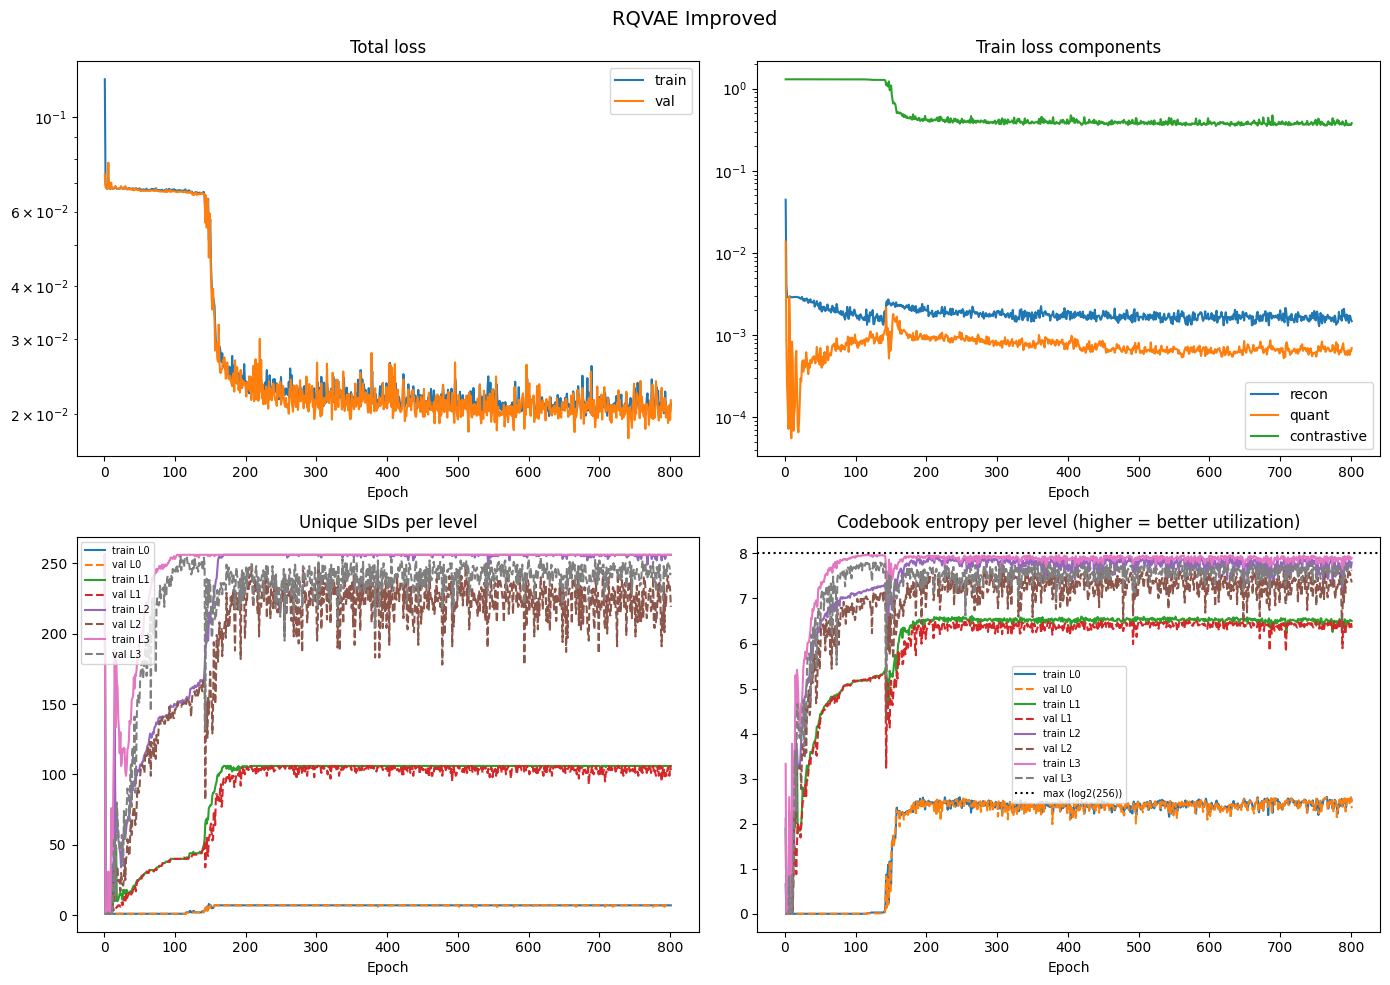

In [21]:
def plot_training(history, title='RQVAE Improved'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=14)

    axes[0,0].plot(epochs, history['train_loss'], label='train')
    axes[0,0].plot(epochs, history['val_loss'],   label='val')
    axes[0,0].set_yscale('log'); axes[0,0].set_title('Total loss')
    axes[0,0].set_xlabel('Epoch'); axes[0,0].legend()

    axes[0,1].plot(epochs, history['train_r_loss'],   label='recon')
    axes[0,1].plot(epochs, history['train_q_loss'],   label='quant')
    axes[0,1].plot(epochs, history['train_con_loss'], label='contrastive')
    axes[0,1].set_yscale('log'); axes[0,1].set_title('Train loss components')
    axes[0,1].set_xlabel('Epoch'); axes[0,1].legend()

    sids_tr = np.array([t.numpy() for t in history['train_sids_num']])
    sids_va = np.array([t.numpy() for t in history['val_sids_num']])
    for lvl in range(sids_tr.shape[1]):
        axes[1,0].plot(epochs, sids_tr[:, lvl], label=f'train L{lvl}')
        axes[1,0].plot(epochs, sids_va[:, lvl], '--', label=f'val L{lvl}')
    axes[1,0].set_title('Unique SIDs per level')
    axes[1,0].set_xlabel('Epoch'); axes[1,0].legend(fontsize=7)

    ent_tr = np.array([t.numpy() for t in history['train_entropy']])
    ent_va = np.array([t.numpy() for t in history['val_entropy']])
    for lvl in range(ent_tr.shape[1]):
        axes[1,1].plot(epochs, ent_tr[:, lvl], label=f'train L{lvl}')
        axes[1,1].plot(epochs, ent_va[:, lvl], '--', label=f'val L{lvl}')
    axes[1,1].axhline(np.log2(codebook_size), color='k', ls=':', label=f'max (log2({codebook_size}))')
    axes[1,1].set_title('Codebook entropy per level (higher = better utilization)')
    axes[1,1].set_xlabel('Epoch'); axes[1,1].legend(fontsize=7)

    plt.tight_layout()
    plt.savefig('rqvae_improved_training.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training(all_history_anti)